# DQN Agent — ALE/Alien-v5

Entrenamiento de un agente Deep Q-Learning para el juego Atari **Alien** usando `ale-py` + `gymnasium` + `pytorch`.

**Ejecutar en Google Colab** (Runtime → Change runtime type → **GPU**).

Estructura:
- **Bloque 0** · Setup e instalación
- **Bloque 1** · Exploración del environment (observaciones, acciones, rewards)
- **Bloque 2** · Preprocesamiento (grayscale, resize, frame stacking)
- Bloque 3 · Arquitecturas DQN *(siguiente paso)*
- Bloque 4 · Componentes de entrenamiento
- Bloque 5 · Training loop con logging
- Bloque 6 · Comparación de arquitecturas
- Bloque 7 · Evaluación y video

## Bloque 0 · Setup

Instalamos las dependencias y verificamos que la GPU esté disponible. `ale-py` 0.8.1+ ya trae los ROMs incluidos, no es necesario descargarlos por separado.

In [26]:
!pip install -q --upgrade "gymnasium[atari]==1.1.1" "ale-py==0.10.2" "autorom[accept-rom-license]"
!AutoROM --accept-license --quiet

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.11/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [23]:
import gymnasium, ale_py
print("Gymnasium:", gymnasium.__version__)   # 1.1.1
print("ALE-py   :", ale_py.__version__)      # 0.10.2
from gymnasium.wrappers import FrameStackObservation 

Gymnasium: 1.2.3
ALE-py   : 0.10.2


In [1]:
!pip install -q "ale-py<0.11" "autorom[accept-rom-license]" --upgrade
!AutoROM --accept-license --quiet

!pip install -q "gymnasium>=1.0" ale-py opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 12.0 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.1 MB/s eta 0:00:00:00:01
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch

# Registrar todos los environments de ALE en el namespace de gymnasium
gym.register_envs(ale_py)

print(f"Python         : {sys.version.split()[0]}")
print(f"Gymnasium      : {gym.__version__}")
print(f"ALE-py         : {ale_py.__version__}")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device usado   : {DEVICE}")

Python         : 3.12.13
Gymnasium      : 1.2.3
ALE-py         : 0.10.2
PyTorch        : 2.10.0+cu128
CUDA disponible: True
GPU            : Tesla T4
Device usado   : cuda


## Bloque 1 · Exploración del environment

Antes de entrenar cualquier agente necesitamos entender el **contrato** que nos da el environment:

- **Observación** · ¿qué ve el agente en cada paso?
- **Acciones** · ¿qué puede hacer?
- **Recompensa** · ¿cómo se mide el éxito?
- **Terminación** · ¿cuándo acaba un episodio?

A diferencia de Blackjack (tupla de 3 enteros), aquí la observación es una **imagen RGB de 210×160×3 píxeles**.

In [3]:
env = gym.make("ALE/Alien-v5", render_mode="rgb_array")
obs, info = env.reset(seed=42)

print("── Observación ────────────────────")
print(f"  Espacio : {env.observation_space}")
print(f"  Shape   : {obs.shape}")
print(f"  Dtype   : {obs.dtype}")
print(f"  Rango   : [{obs.min()}, {obs.max()}]")

print("\n── Acciones ──────────────────────")
print(f"  Espacio     : {env.action_space}")
print(f"  N° acciones : {env.action_space.n}")

action_meanings = env.unwrapped.get_action_meanings()
print(f"\n  Significado de cada acción:")
for i, name in enumerate(action_meanings):
    print(f"    {i:2d} → {name}")

print("\n── Info inicial ───────────────────")
print(f"  {info}")

── Observación ────────────────────
  Espacio : Box(0, 255, (210, 160, 3), uint8)
  Shape   : (210, 160, 3)
  Dtype   : uint8
  Rango   : [0, 252]

── Acciones ──────────────────────
  Espacio     : Discrete(18)
  N° acciones : 18

  Significado de cada acción:
     0 → NOOP
     1 → FIRE
     2 → UP
     3 → RIGHT
     4 → LEFT
     5 → DOWN
     6 → UPRIGHT
     7 → UPLEFT
     8 → DOWNRIGHT
     9 → DOWNLEFT
    10 → UPFIRE
    11 → RIGHTFIRE
    12 → LEFTFIRE
    13 → DOWNFIRE
    14 → UPRIGHTFIRE
    15 → UPLEFTFIRE
    16 → DOWNRIGHTFIRE
    17 → DOWNLEFTFIRE

── Info inicial ───────────────────
  {'lives': 3, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(3444837047), np.uint32(2669555309))}


### Visualizar la observación (frame RGB)

El agente recibe literalmente la pantalla del Atari. Mostramos el frame inicial y los que resultan de aplicar tres acciones aleatorias.

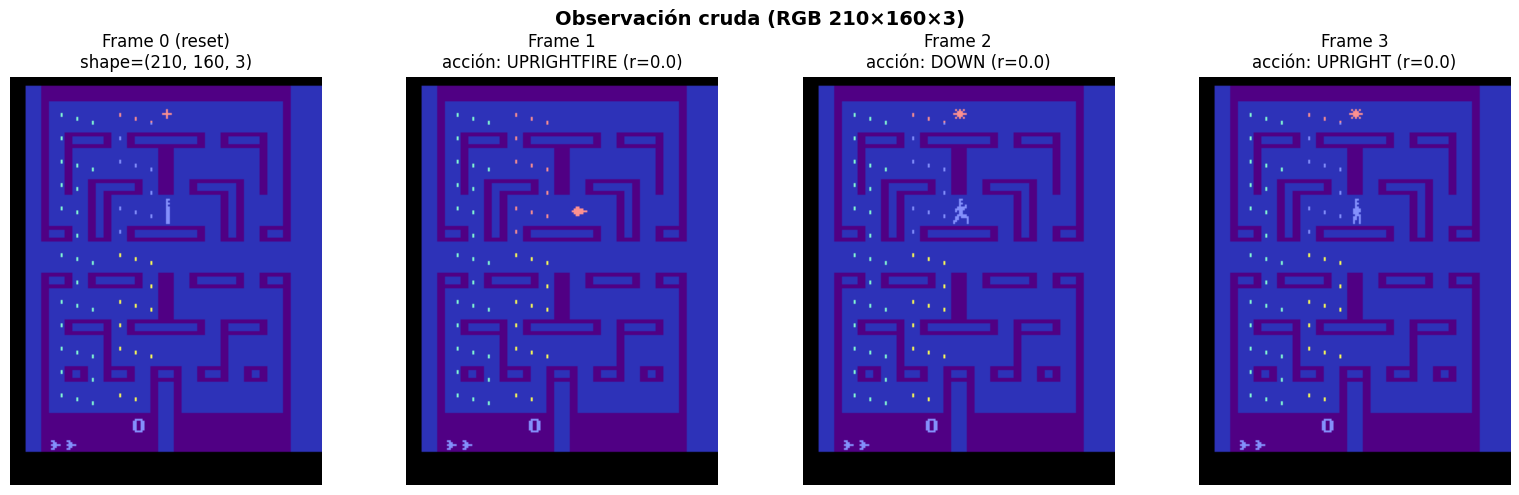

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
obs, _ = env.reset(seed=0)
axes[0].imshow(obs)
axes[0].set_title(f"Frame 0 (reset)\nshape={obs.shape}")
axes[0].axis("off")

for i in range(1, 4):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    axes[i].imshow(obs)
    axes[i].set_title(f"Frame {i}\nacción: {action_meanings[action]} (r={reward})")
    axes[i].axis("off")

plt.suptitle("Observación cruda (RGB 210×160×3)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Episodio con política aleatoria

Jugamos un episodio completo tomando acciones al azar. Sirve como **baseline**: el DQN debe superar claramente este nivel de rendimiento al final del entrenamiento.

In [5]:
obs, _ = env.reset(seed=123)
step_rewards = []
actions_taken = []
total_reward = 0.0
done = False

while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    step_rewards.append(reward)
    actions_taken.append(action)
    total_reward += reward
    done = terminated or truncated

print("── Episodio aleatorio ────────────────")
print(f"  Longitud              : {len(step_rewards)} pasos")
print(f"  Reward total          : {total_reward}")
print(f"  Pasos con reward > 0  : {sum(1 for r in step_rewards if r > 0)}")
print(f"  Reward máximo por paso: {max(step_rewards) if step_rewards else 0}")
print(f"  Info final            : {info}")

── Episodio aleatorio ────────────────
  Longitud              : 854 pasos
  Reward total          : 220.0
  Pasos con reward > 0  : 22
  Reward máximo por paso: 10.0
  Info final            : {'lives': 0, 'episode_frame_number': 3413, 'frame_number': 3413}


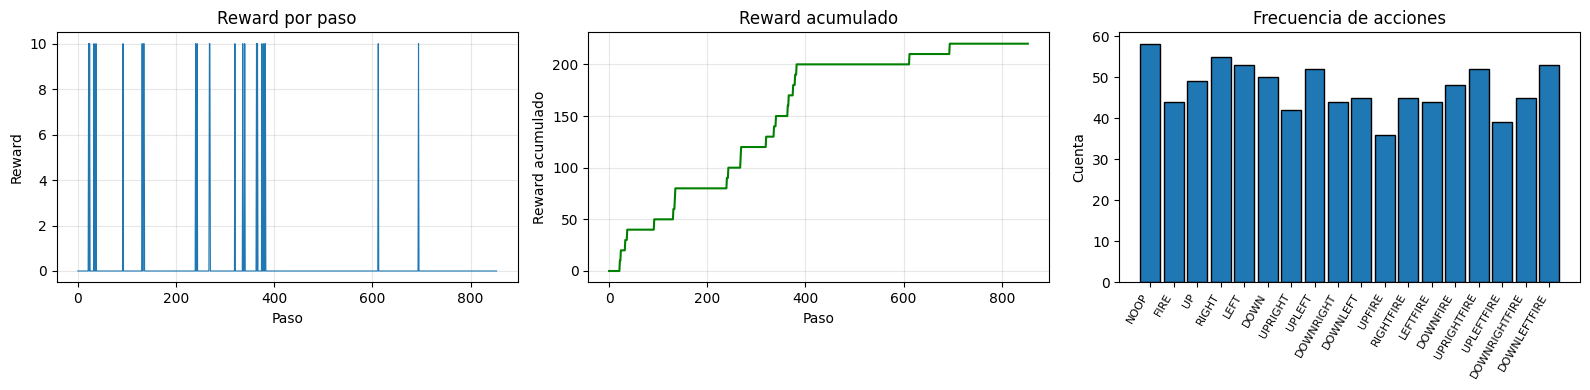

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(step_rewards, linewidth=0.8)
axes[0].set_title("Reward por paso")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Reward")
axes[0].grid(alpha=0.3)

axes[1].plot(np.cumsum(step_rewards), color="green")
axes[1].set_title("Reward acumulado")
axes[1].set_xlabel("Paso")
axes[1].set_ylabel("Reward acumulado")
axes[1].grid(alpha=0.3)

axes[2].hist(actions_taken, bins=np.arange(env.action_space.n + 1) - 0.5,
             edgecolor="black", rwidth=0.85)
axes[2].set_xticks(range(env.action_space.n))
axes[2].set_xticklabels(action_meanings, rotation=60, ha="right", fontsize=8)
axes[2].set_title("Frecuencia de acciones")
axes[2].set_ylabel("Cuenta")

plt.tight_layout()
plt.show()

env.close()

**Lectura de estos gráficos:**
- El reward es **escaso (sparse)**: el agente recibe puntos solo cuando destruye un huevo, mata un alien o recoge un pulsar. Esto hace el problema difícil para Q-Learning.
- Con acciones aleatorias las recompensas por paso son mayormente cero y los picos son pequeños.
- Una política aleatoria sobre 18 acciones las usa de forma aproximadamente uniforme.

## Bloque 2 · Preprocesamiento

Entrenar una CNN sobre imágenes 210×160×3 es viable pero innecesariamente caro. El **pipeline estándar de Atari** (DeepMind Nature 2015) reduce la observación a algo manejable manteniendo lo importante:

| Paso | Qué hace | Por qué |
|---|---|---|
| **NoOp reset** | Ejecuta entre 0 y 30 acciones NOOP al reiniciar | Aleatoriza el estado inicial |
| **Frame skip = 4** | Repite la acción 4 frames; solo devuelve el último | Acelera simulación ×4; decisiones cada 4 frames son suficientes |
| **Max pooling** | Toma el máximo entre los últimos 2 frames | Evita parpadeos propios del hardware Atari |
| **Grayscale** | RGB → escala de grises (1 canal) | Reduce dimensionalidad ×3 sin perder información útil |
| **Resize 84×84** | Downsample desde 210×160 | Tamaño canónico del paper original |
| **Frame stack = 4** | Apila los 4 últimos frames preprocesados | Da al agente información de **movimiento** (posición + velocidad) |

Resultado final: tensor **(4, 84, 84)** en `uint8`. Mantenemos `uint8` en el replay buffer para ahorrar memoria; normalizaremos a `[0,1]` dentro del forward de la red.

In [7]:
import gymnasium as gym
import numpy as np, cv2

class SimpleAtariPreprocessing(gym.Wrapper):
    def __init__(self, env, noop_max=30, frame_skip=4, screen_size=84,
                terminal_on_life_loss=False):
        super().__init__(env)
        self.noop_max = noop_max
        self.frame_skip = frame_skip
        self.screen_size = screen_size
        self.terminal_on_life_loss = terminal_on_life_loss
        self.obs_buffer = np.zeros((2, 210, 160), dtype=np.uint8)
        self.lives = 0
        self.observation_space = gym.spaces.Box(
            0, 255, (screen_size, screen_size), dtype=np.uint8)

    def _frame(self, rgb):
        return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY) if rgb.ndim == 3 else rgb

    def _pool_resize(self):
        pooled = np.maximum(self.obs_buffer[0], self.obs_buffer[1])
        return cv2.resize(pooled, (self.screen_size, self.screen_size),
                        interpolation=cv2.INTER_AREA)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        noops = np.random.randint(1, self.noop_max + 1) if self.noop_max > 0 else 0
        for _ in range(noops):
            obs, _, term, trunc, info = self.env.step(0)
            if term or trunc:
                obs, info = self.env.reset(**kwargs)
        self.lives = self.env.unwrapped.ale.lives()
        self.obs_buffer[0] = self._frame(obs)
        self.obs_buffer[1] = 0
        return self._pool_resize(), info

    def step(self, action):
        total_r = 0.0
        term = trunc = False
        for i in range(self.frame_skip):
            obs, r, term, trunc, info = self.env.step(action)
            total_r += r
            if i == self.frame_skip - 2:
                self.obs_buffer[1] = self._frame(obs)
            if i == self.frame_skip - 1:
                self.obs_buffer[0] = self._frame(obs)
            if term or trunc:
                break
        if self.terminal_on_life_loss:
            lives = self.env.unwrapped.ale.lives()
            if 0 < lives < self.lives:
                term = True
            self.lives = lives
        return self._pool_resize(), total_r, term, trunc, info

In [8]:
import gymnasium as gym                                                                                                                            
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
                                                                                                                                                    
                
def make_env(
    env_id: str = "ALE/Alien-v5",
    seed: int = 0,
    render_mode=None,
    terminal_on_life_loss: bool = False,
    full_action_space: bool = False,
):
    """Crea el environment Alien con el pipeline estándar de Atari.

    Args:
        terminal_on_life_loss: True en entrenamiento (aprende más rápido),
            False en evaluación (para medir el score real del episodio).
        full_action_space: False usa el conjunto mínimo de acciones del juego.
    """
    env = gym.make(
        env_id,
        frameskip=1,
        render_mode=render_mode,
        full_action_space=full_action_space,
    )
    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        terminal_on_life_loss=terminal_on_life_loss,
        grayscale_obs=True,
        grayscale_newaxis=False,
        scale_obs=False,
    )
    env = FrameStackObservation(env, stack_size=4)
    env.reset(seed=seed)
    return env


def make_env_train(seed: int = 0, **kw):
    return make_env(seed=seed, terminal_on_life_loss=True, full_action_space=False, **kw)


def make_env_eval(seed: int = 0, **kw):
    return make_env(seed=seed, terminal_on_life_loss=False, full_action_space=False, **kw)


# ── Verificación ──────────────────
env_tr = make_env_train(seed=0)
env_ev = make_env_eval(seed=0)

print("Observation space (train):", env_tr.observation_space)
print("Observation space (eval) :", env_ev.observation_space)
print("Action space            :", env_tr.action_space)
print("N° acciones             :", env_tr.action_space.n)

obs, info = env_tr.reset()
print("Obs shape tras reset    :", obs.shape, " dtype:", obs.dtype)

env_tr.close()
env_ev.close()

Observation space (train): Box(0, 255, (4, 84, 84), uint8)
Observation space (eval) : Box(0, 255, (4, 84, 84), uint8)
Action space            : Discrete(18)
N° acciones             : 18
Obs shape tras reset    : (4, 84, 84)  dtype: uint8


### Comparación visual antes/después

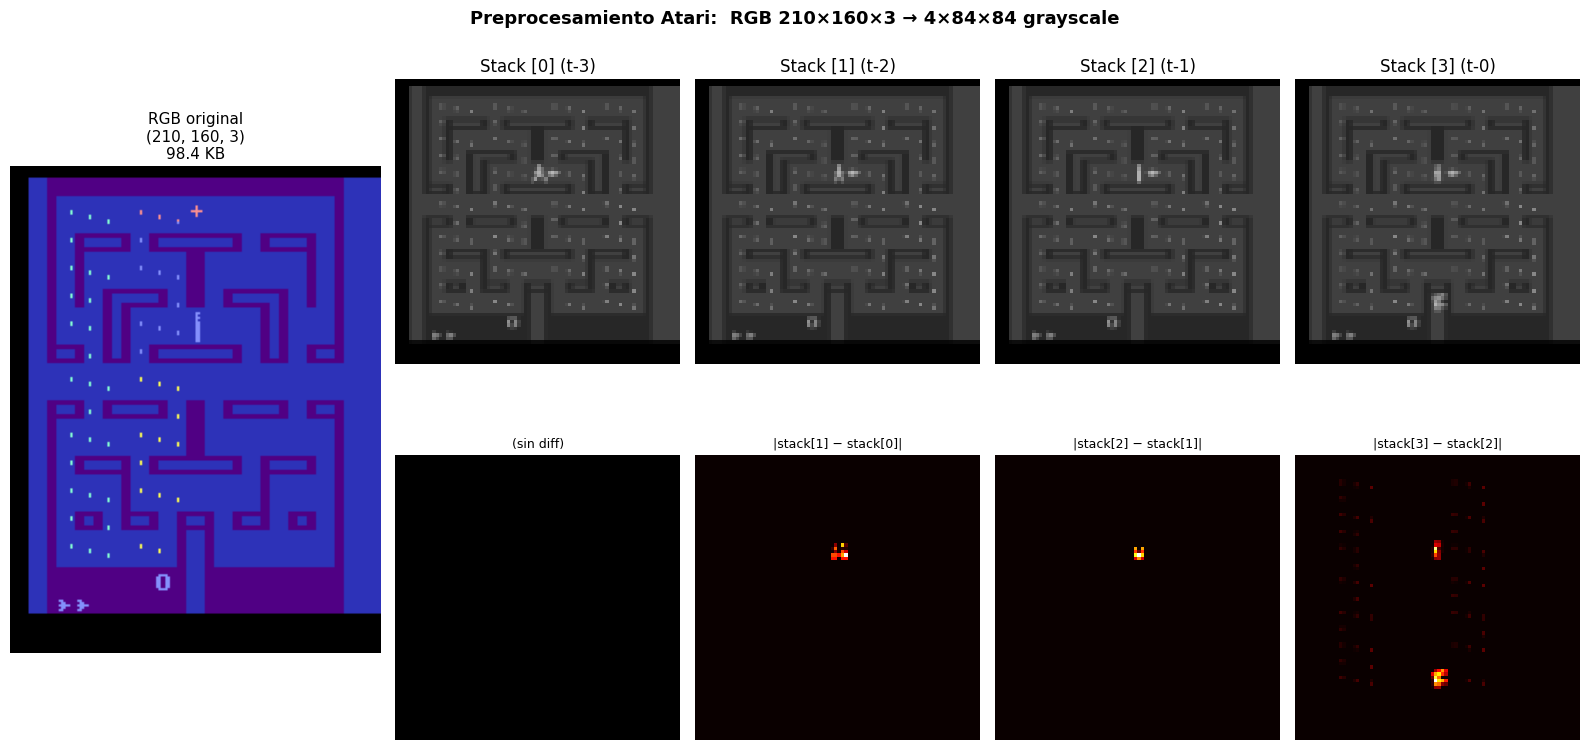

In [10]:
# Frame RGB original para referencia
raw_env = gym.make("ALE/Alien-v5")
raw_obs, _ = raw_env.reset(seed=42)

# Avanzamos unos pasos en el env preprocesado para llenar el frame stack con variación
stacked_obs, _ = env_tr.reset(seed=42)
for _ in range(10):
    stacked_obs, _, term, trunc, _ = env_tr.step(env_tr.action_space.sample())
    if term or trunc:
        stacked_obs, _ = env_tr.reset(seed=42)

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 5, width_ratios=[1.3, 1, 1, 1, 1])

# Imagen cruda a la izquierda (grande)
ax_raw = fig.add_subplot(gs[:, 0])
ax_raw.imshow(raw_obs)
ax_raw.set_title(f"RGB original\n{raw_obs.shape}\n{raw_obs.nbytes/1024:.1f} KB", fontsize=11)
ax_raw.axis("off")

# Los 4 frames apilados (arriba)
for i in range(4):
    ax = fig.add_subplot(gs[0, i + 1])
    ax.imshow(stacked_obs[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Stack [{i}] (t-{3-i})")
    ax.axis("off")

# La diferencia entre frames consecutivos (muestra movimiento)
for i in range(4):
    ax = fig.add_subplot(gs[1, i + 1])
    if i == 0:
        ax.imshow(np.zeros_like(stacked_obs[0]), cmap="gray", vmin=0, vmax=255)
        ax.set_title("(sin diff)", fontsize=9)
    else:
        diff = np.abs(stacked_obs[i].astype(int) - stacked_obs[i - 1].astype(int)).astype(np.uint8)
        ax.imshow(diff, cmap="hot")
        ax.set_title(f"|stack[{i}] − stack[{i-1}]|", fontsize=9)
    ax.axis("off")

plt.suptitle("Preprocesamiento Atari:  RGB 210×160×3 → 4×84×84 grayscale",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

raw_env.close()

**Interpretación:**
- La fila superior muestra los **4 frames apilados** que el agente verá como una sola observación. Es su "memoria" visual de los últimos instantes.
- La fila inferior muestra la diferencia entre frames consecutivos — los píxeles calientes son justamente las zonas con **movimiento** (aliens, jugador). Esto es lo que la CNN puede aprender a detectar.
- Reducimos el tamaño de ~100 KB por observación a ~28 KB: un replay buffer de 100k experiencias cabe en ~2.8 GB.

In [12]:
# Sanity check: un episodio completo con el env preprocesado
obs, _ = env_tr.reset(seed=0)
ep_reward, ep_len = 0.0, 0
done = False

while not done:
    action = env_tr.action_space.sample()
    obs, reward, term, trunc, _ = env_tr.step(action)
    ep_reward += reward
    ep_len += 1
    done = term or trunc

print(f"Episodio aleatorio (env preprocesado):")
print(f"  Decisiones del agente: {ep_len}  (× frame_skip=4 → {ep_len*4} frames reales)")
print(f"  Reward total: {ep_reward}")

env_tr.close()

Episodio aleatorio (env preprocesado):
  Decisiones del agente: 202  (× frame_skip=4 → 808 frames reales)
  Reward total: 30.0


---

**Listo Bloques 0-2**. Ahora tenemos:

- Environment instalado y GPU detectada
- Claridad sobre observaciones (210×160×3), acciones (18) y recompensas (dispersas)
- Pipeline de preprocesamiento que entrega tensores `(4, 84, 84) uint8` listos para una CNN
- Función `make_env()` reutilizable que usaremos en todo el entrenamiento

**Siguiente paso**: definir las 4 arquitecturas DQN (Vanilla, Double, Dueling, Double+Dueling) y el replay buffer.

# ReplayBuffer
guardamos las últimas N transiciones (s, a, r, s', done) en una memoria circular. En cada paso de aprendizaje
  muestreamos un batch aleatorio de esa memoria. Así decorrelacionamos muestras y reutilizamos experiencia muchas veces.

In [13]:
import random
import numpy as np
import torch


class ReplayBuffer:
    """Memoria circular de transiciones (s, a, r, s', done).

    Guarda observaciones en uint8 para ahorrar memoria; las convierte
    a float32 y normaliza a [0, 1] en el momento de muestrear.
    """

    def __init__(self, capacity: int, obs_shape: tuple, device: torch.device):
        self.capacity = capacity
        self.device = device
        self.idx = 0
        self.size = 0

        # Pre-alocamos arrays (evita fragmentación de memoria)
        self.states      = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_states = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        self.states[self.idx]      = state
        self.next_states[self.idx] = next_state
        self.actions[self.idx]     = action
        self.rewards[self.idx]     = reward
        self.dones[self.idx]       = float(done)

        self.idx = (self.idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        indices = np.random.randint(0, self.size, size=batch_size)

        s  = torch.from_numpy(self.states[indices]).float().to(self.device) / 255.0
        s2 = torch.from_numpy(self.next_states[indices]).float().to(self.device) / 255.0
        a  = torch.from_numpy(self.actions[indices]).to(self.device)
        r  = torch.from_numpy(self.rewards[indices]).to(self.device)
        d  = torch.from_numpy(self.dones[indices]).to(self.device)

        return s, a, r, s2, d

    def __len__(self):
        return self.size


# ── Test rápido ──────────────────────
buf = ReplayBuffer(capacity=1000, obs_shape=(4, 84, 84), device=DEVICE)
dummy_obs = np.zeros((4, 84, 84), dtype=np.uint8)
for _ in range(50):
    buf.push(dummy_obs, 0, 0.0, dummy_obs, False)

s, a, r, s2, d = buf.sample(32)
print(f"Buffer llenado con {len(buf)} transiciones")
print(f"  states shape : {s.shape}  dtype: {s.dtype}  rango: [{s.min():.2f}, {s.max():.2f}]")
print(f"  actions shape: {a.shape}  dtype: {a.dtype}")
print(f"  rewards shape: {r.shape}  dtype: {r.dtype}")
print(f"  dones shape  : {d.shape}  dtype: {d.dtype}")

mem_mb = (buf.states.nbytes + buf.next_states.nbytes) / 1024**2
print(f"\n  Memoria ocupada por el buffer de 1000: {mem_mb:.1f} MB")
print(f"  Proyección para 50k transiciones    : {mem_mb * 50:.1f} MB")

Buffer llenado con 50 transiciones
  states shape : torch.Size([32, 4, 84, 84])  dtype: torch.float32  rango: [0.00, 0.00]
  actions shape: torch.Size([32])  dtype: torch.int64
  rewards shape: torch.Size([32])  dtype: torch.float32
  dones shape  : torch.Size([32])  dtype: torch.float32

  Memoria ocupada por el buffer de 1000: 53.8 MB
  Proyección para 50k transiciones    : 2691.7 MB


# Entrenamiento

### Arquitectura Vanilla DQN (arquitectura Nature)

  La arquitectura canónica del paper de DeepMind (Mnih et al. 2015, Human-level control through deep reinforcement learning):

  Input (4, 84, 84)
    ↓ Conv 8×8, stride 4, 32 filtros  → (32, 20, 20)
    ↓ Conv 4×4, stride 2, 64 filtros  → (64, 9, 9)
    ↓ Conv 3×3, stride 1, 64 filtros  → (64, 7, 7)
    ↓ Flatten                          → 3136
    ↓ Linear 3136 → 512
    ↓ Linear 512  → n_actions
  Output: Q(s, ·)  — un valor por acción


In [14]:
import torch.nn as nn

class VanillaDQN(nn.Module):
    """CNN Nature DQN (Mnih et al. 2015).

    Input : (B, 4, 84, 84) en [0, 1]
    Output: (B, n_actions)  — Q(s, ·)
    """

    def __init__(self, n_actions: int, in_channels: int = 4):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4),  # 84 → 20
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),            # 20 → 9
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),            # 9  → 7
            nn.ReLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.conv(x))


# ── Test: inferencia dummy ────────────
N_ACTIONS = 18
net = VanillaDQN(n_actions=N_ACTIONS).to(DEVICE)

dummy_batch = torch.zeros(8, 4, 84, 84, device=DEVICE)
with torch.no_grad():
    q_values = net(dummy_batch)

n_params = sum(p.numel() for p in net.parameters())
print(f"VanillaDQN:")
print(f"  Input  : {tuple(dummy_batch.shape)}")
print(f"  Output : {tuple(q_values.shape)}  (1 Q-value por acción)")
print(f"  Parámetros totales: {n_params:,}")
print(f"\n  Ejemplo de Q-values para la primera muestra:")
print(f"  {q_values[0].cpu().numpy().round(3)}")

VanillaDQN:
  Input  : (8, 4, 84, 84)
  Output : (8, 18)  (1 Q-value por acción)
  Parámetros totales: 1,693,362

  Ejemplo de Q-values para la primera muestra:
  [-0.044 -0.032  0.001  0.027  0.007 -0.014 -0.016 -0.01  -0.035 -0.008
 -0.018  0.001 -0.04  -0.001  0.027  0.044 -0.015 -0.023]


### Arquitectura DuelingDQN  

In [15]:
class DuelingDQN(nn.Module):
    """
    Dueling DQN (Wang et al., 2016).
    Separa el estimador en V(s) (valor del estado) y A(s,a) (ventaja de cada acción).
    Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a))    <-- la resta estabiliza el aprendizaje
    """
    def __init__(self, n_actions, in_channels=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=8, stride=4), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(inplace=True),
            nn.Flatten(),
        )
        feat_dim = 64 * 7 * 7
        self.value_stream = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(inplace=True),
            nn.Linear(512, 1),
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(inplace=True),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        feat = self.conv(x)
        v = self.value_stream(feat)                      # (B, 1)
        a = self.advantage_stream(feat)                  # (B, n_actions)
        return v + (a - a.mean(dim=1, keepdim=True))     # (B, n_actions)

# Verificación
_net = DuelingDQN(n_actions=18)
n_params = sum(p.numel() for p in _net.parameters())
print(f"DuelingDQN params: {n_params:,}")   # ~2.22M (vs 1.69M vanilla)

DuelingDQN params: 3,300,019


### Config de hiperparámetros

Un dataclass para trackear todos los hiperparámetros en un solo lugar. 

In [16]:
from dataclasses import dataclass, asdict, field
from typing import Optional


@dataclass
class DQNConfig:
    # Environment
    n_actions: int = 18
    obs_shape: tuple = (4, 84, 84)

    # Optimización
    learning_rate: float = 1e-4
    batch_size: int = 32
    gamma: float = 0.99
    grad_clip: Optional[float] = 10.0

    # Replay buffer
    buffer_capacity: int = 50_000
    min_buffer_size: int = 5_000      # warmup antes de aprender

    # Target network
    target_update_freq: int = 1_000   # cada N updates de gradiente

    # Epsilon-greedy
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay_steps: int = 100_000

    # Rewards
    reward_clip: Optional[float] = 1.0  # None = sin clip

    # Loop de training
    train_every: int = 4              # pasos del env por update de gradiente

    # Variante DQN (para reutilizar el Agent luego)
    double_dqn: bool = False

    # Etiqueta identificadora del experimento
    label: str = "vanilla_dqn"


cfg_vanilla = DQNConfig(n_actions=  18, label="vanilla_dqn")
print(cfg_vanilla)

DQNConfig(n_actions=18, obs_shape=(4, 84, 84), learning_rate=0.0001, batch_size=32, gamma=0.99, grad_clip=10.0, buffer_capacity=50000, min_buffer_size=5000, target_update_freq=1000, eps_start=1.0, eps_end=0.05, eps_decay_steps=100000, reward_clip=1.0, train_every=4, double_dqn=False, label='vanilla_dqn')


### EpsilonScheduler
Calcula ε dado el paso actual. Decay lineal de eps_start a eps_end a lo largo de decay_steps.

In [17]:
class EpsilonScheduler:
    def __init__(self, eps_start: float, eps_end: float, decay_steps: int):
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.decay_steps = decay_steps

    def value(self, step: int) -> float:
        fraction = min(step / self.decay_steps, 1.0)
        return self.eps_start + fraction * (self.eps_end - self.eps_start)

### DQNAgent (genérico sobre la arquitectura)

Recibe una clase de red como parámetro (network_cls). Así el mismo DQNAgent servirá para VanillaDQN, DuelingDQN, etc. más adelante.

La ecuación de Bellman implementada en update():

$$
\text{target} = r + \gamma \cdot \max_{a'} Q_{\text{target}}(s', a') \cdot (1 - \text{done})
$$

$$
\mathcal{L} = \text{SmoothL1}(Q_\text{online}(s, a), \text{target})
$$

Usamos Smooth L1 (Huber loss) en lugar de MSE: más robusta a outliers, estándar en DQN moderno.

In [18]:
import torch.nn as nn
import torch.nn.functional as F
class DQNAgent:
    """Agente DQN genérico sobre cualquier arquitectura CNN.

    Args:
        network_cls: clase de red (ej: VanillaDQN). Debe aceptar
            n_actions en su constructor y recibir tensores (B, 4, 84, 84).
    """

    def __init__(self, network_cls, config: DQNConfig, device: torch.device):
        self.config = config
        self.device = device

        # Online + target network (mismos pesos al inicio)
        self.q_net = network_cls(n_actions=config.n_actions).to(device)
        self.target_net = network_cls(n_actions=config.n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(),
                                        lr=config.learning_rate)

        self.eps_scheduler = EpsilonScheduler(
            config.eps_start, config.eps_end, config.eps_decay_steps
        )

        self.gradient_steps = 0  # contador de updates

    def select_action(self, state: np.ndarray, step: int,
                    eval_mode: bool = False) -> int:
        """Epsilon-greedy. En eval_mode, eps=0 (siempre greedy)."""
        epsilon = 0.0 if eval_mode else self.eps_scheduler.value(step)
        if np.random.random() < epsilon:
            return np.random.randint(self.config.n_actions)
        with torch.no_grad():
            s = torch.from_numpy(np.asarray(state)).float().unsqueeze(0).to(self.device) / 255.0
            q = self.q_net(s)
            return int(q.argmax(dim=1).item())

    def update(self, buffer: ReplayBuffer) -> Optional[dict]:
        """Un paso de gradiente. Devuelve métricas o None si el buffer es pequeño."""
        if len(buffer) < self.config.min_buffer_size:
            return None

        s, a, r, s2, d = buffer.sample(self.config.batch_size)

        if self.config.reward_clip is not None:
            r = r.clamp(-self.config.reward_clip, self.config.reward_clip)

        # Q(s, a): valor actual de la acción que tomamos
        q_current = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Target Bellman
        with torch.no_grad():
            if self.config.double_dqn:
                # Online elige la acción, target la evalúa
                next_actions = self.q_net(s2).argmax(dim=1, keepdim=True)
                q_next = self.target_net(s2).gather(1, next_actions).squeeze(1)
            else:
                # DQN vanilla: target hace todo
                q_next = self.target_net(s2).max(dim=1).values

            target = r + self.config.gamma * q_next * (1.0 - d)

        loss = F.smooth_l1_loss(q_current, target)

        self.optimizer.zero_grad()
        loss.backward()
        if self.config.grad_clip is not None:
            nn.utils.clip_grad_norm_(self.q_net.parameters(), self.config.grad_clip)
        self.optimizer.step()

        self.gradient_steps += 1

        # Hard update del target cada N updates
        if self.gradient_steps % self.config.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return {
            "loss":        loss.item(),
            "q_mean":      q_current.mean().item(),
            "target_mean": target.mean().item(),
        }

### 
Llenamos el buffer con transiciones reales del env y ejecutamos unos pocos update() para verificar que el pipeline completo funciona antes del training loop grande.

In [19]:
# Config chica para el test (min_buffer_size bajo, decay rápido)
test_cfg = DQNConfig(
    n_actions=18,
    min_buffer_size=100,
    eps_decay_steps=1_000,
    target_update_freq=10,
    label="test_vanilla",
)

agent = DQNAgent(network_cls=VanillaDQN, config=test_cfg, device=DEVICE)
buffer = ReplayBuffer(test_cfg.buffer_capacity, test_cfg.obs_shape, DEVICE)

env = make_env_train(seed=0)
obs, _ = env.reset(seed=0)

# Llenar el buffer con 300 transiciones aleatorias
for _ in range(300):
    action = env.action_space.sample()
    next_obs, reward, term, trunc, _ = env.step(action)
    buffer.push(np.array(obs), action, reward, np.array(next_obs), term or trunc)
    obs = next_obs
    if term or trunc:
        obs, _ = env.reset()

print(f"Buffer llenado con {len(buffer)} transiciones\n")

print("── 10 updates de prueba ──────────────")
for i in range(10):
    m = agent.update(buffer)
    print(f"  update {i+1:2d}:  loss={m['loss']:.4f}  "
        f"Q_mean={m['q_mean']:+.3f}  target_mean={m['target_mean']:+.3f}")

print(f"\nTotal gradient steps: {agent.gradient_steps}")
print(f"Target net se sincronizó {agent.gradient_steps // test_cfg.target_update_freq} veces")

# Test de selección de acción
action_explore = agent.select_action(np.array(obs), step=0)
action_greedy  = agent.select_action(np.array(obs), step=0, eval_mode=True)
print(f"\nAcción con eps={agent.eps_scheduler.value(0):.2f}: {action_explore}")
print(f"Acción greedy (eval_mode=True)      : {action_greedy}")

env.close()

Buffer llenado con 300 transiciones

── 10 updates de prueba ──────────────
  update  1:  loss=0.0188  Q_mean=-0.003  target_mean=+0.064
  update  2:  loss=0.0009  Q_mean=-0.004  target_mean=+0.033
  update  3:  loss=0.0006  Q_mean=+0.003  target_mean=+0.033
  update  4:  loss=0.0178  Q_mean=-0.005  target_mean=+0.064
  update  5:  loss=0.0339  Q_mean=-0.000  target_mean=+0.094
  update  6:  loss=0.0496  Q_mean=+0.011  target_mean=+0.126
  update  7:  loss=0.0178  Q_mean=+0.011  target_mean=+0.064
  update  8:  loss=0.0157  Q_mean=+0.020  target_mean=+0.064
  update  9:  loss=0.0471  Q_mean=+0.016  target_mean=+0.126
  update 10:  loss=0.0344  Q_mean=+0.016  target_mean=+0.095

Total gradient steps: 10
Target net se sincronizó 1 veces

Acción con eps=1.00: 15
Acción greedy (eval_mode=True)      : 1


# Training Loop
Función evaluate_agent + train

In [20]:
from tqdm.auto import tqdm
                                                                                                                                                                                                                                             
def evaluate_agent(agent, n_episodes: int = 3, seed_base: int = 1000):                                                        
    """Corre `n_episodes` en env de evaluación (eps=0, 3 vidas)."""                                                           
    env = make_env_eval(seed=seed_base)                                                                                       
    rewards = []                                                                                                              
    for i in range(n_episodes):                                                                                               
        obs, _ = env.reset(seed=seed_base + i)
        ep_r, done = 0.0, False
        while not done:
            action = agent.select_action(np.array(obs), step=0, eval_mode=True)
            obs, r, term, trunc, _ = env.step(action)
            ep_r += r
            done = term or trunc
        rewards.append(ep_r)
    env.close()
    return float(np.mean(rewards)), float(np.std(rewards))


def train(agent, config, total_steps: int,
        eval_every: int = 10_000, n_eval_episodes: int = 3, seed: int = 0):
    """Training loop principal. Devuelve un dict con todas las métricas."""
    env = make_env_train(seed=seed)
    buffer = ReplayBuffer(config.buffer_capacity, config.obs_shape, agent.device)

    history = {
        "episode_rewards":   [],
        "episode_lengths":   [],
        "episode_losses":    [],
        "episode_q_means":   [],
        "episode_epsilons":  [],
        "episode_end_steps": [],
        "eval_steps":        [],
        "eval_mean_rewards": [],
        "eval_std_rewards":  [],
    }

    obs, _ = env.reset(seed=seed)
    ep_reward, ep_length = 0.0, 0
    ep_losses, ep_q_means = [], []

    pbar = tqdm(range(total_steps), desc=f"Training {config.label}")
    for step in pbar:
        action = agent.select_action(np.array(obs), step=step)
        next_obs, reward, term, trunc, _ = env.step(action)
        done = term or trunc

        buffer.push(np.array(obs), action, reward, np.array(next_obs), done)
        ep_reward += reward
        ep_length += 1
        obs = next_obs

        # Un update de gradiente cada `train_every` pasos del env
        if step % config.train_every == 0:
            m = agent.update(buffer)
            if m is not None:
                ep_losses.append(m["loss"])
                ep_q_means.append(m["q_mean"])

        if done:
            history["episode_rewards"].append(ep_reward)
            history["episode_lengths"].append(ep_length)
            history["episode_losses"].append(np.mean(ep_losses) if ep_losses else 0.0)
            history["episode_q_means"].append(np.mean(ep_q_means) if ep_q_means else 0.0)
            history["episode_epsilons"].append(agent.eps_scheduler.value(step))
            history["episode_end_steps"].append(step)

            r_avg = np.mean(history["episode_rewards"][-20:])
            pbar.set_postfix({
                "ep": len(history["episode_rewards"]),
                "r_avg20": f"{r_avg:.0f}",
                "eps": f"{history['episode_epsilons'][-1]:.2f}",
            })

            obs, _ = env.reset()
            ep_reward, ep_length = 0.0, 0
            ep_losses, ep_q_means = [], []

        if (step + 1) % eval_every == 0:
            mean_r, std_r = evaluate_agent(agent, n_episodes=n_eval_episodes)
            history["eval_steps"].append(step + 1)
            history["eval_mean_rewards"].append(mean_r)
            history["eval_std_rewards"].append(std_r)
            pbar.write(f"[step {step+1:>7,}]  eval reward = {mean_r:7.1f} ± {std_r:.1f}")

    env.close()
    return history

## Entrenamiento Vanilla DQN (100k pasos)

In [21]:
import pickle

cfg_vanilla = DQNConfig(
    n_actions=18,
    learning_rate=1e-4,
    batch_size=32,
    gamma=0.99,
    buffer_capacity=50_000,
    min_buffer_size=5_000,        # 5k pasos de pura exploración random
    target_update_freq=1_000,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50_000,       # eps llega al mínimo a mitad del training
    reward_clip=1.0,
    train_every=4,
    double_dqn=False,
    label="vanilla_dqn",
)

print("── Configuración del experimento ─────────")
for k, v in asdict(cfg_vanilla).items():
    print(f"  {k:22s}: {v}")

# Agente nuevo
agent_vanilla = DQNAgent(network_cls=VanillaDQN, config=cfg_vanilla, device=DEVICE)

# Entrenar
TOTAL_STEPS = 100_000
history_vanilla = train(
    agent=agent_vanilla,
    config=cfg_vanilla,
    total_steps=TOTAL_STEPS,
    eval_every=10_000,
    n_eval_episodes=3,
    seed=42,
)

# Persistir pesos + historial + config
torch.save(agent_vanilla.q_net.state_dict(), f"{cfg_vanilla.label}_weights.pt")
with open(f"{cfg_vanilla.label}_run.pkl", "wb") as f:
    pickle.dump({"config": asdict(cfg_vanilla), "history": history_vanilla}, f)

print(f"\n✓ Guardado: {cfg_vanilla.label}_weights.pt")
print(f"✓ Guardado: {cfg_vanilla.label}_run.pkl")
print(f"✓ Total de episodios: {len(history_vanilla['episode_rewards'])}")
print(f"✓ Último eval reward: "
    f"{history_vanilla['eval_mean_rewards'][-1]:.1f} ± "
    f"{history_vanilla['eval_std_rewards'][-1]:.1f}")

── Configuración del experimento ─────────
  n_actions             : 18
  obs_shape             : (4, 84, 84)
  learning_rate         : 0.0001
  batch_size            : 32
  gamma                 : 0.99
  grad_clip             : 10.0
  buffer_capacity       : 50000
  min_buffer_size       : 5000
  target_update_freq    : 1000
  eps_start             : 1.0
  eps_end               : 0.05
  eps_decay_steps       : 50000
  reward_clip           : 1.0
  train_every           : 4
  double_dqn            : False
  label                 : vanilla_dqn


Training vanilla_dqn:   0%|          | 0/100000 [00:00<?, ?it/s]

[step  10,000]  eval reward =     0.0 ± 0.0
[step  20,000]  eval reward =   100.0 ± 0.0
[step  30,000]  eval reward =   180.0 ± 65.3
[step  40,000]  eval reward =   173.3 ± 26.2
[step  50,000]  eval reward =   293.3 ± 74.1
[step  60,000]  eval reward =   246.7 ± 69.4
[step  70,000]  eval reward =   223.3 ± 81.8
[step  80,000]  eval reward =   240.0 ± 81.6
[step  90,000]  eval reward =   310.0 ± 102.0
[step 100,000]  eval reward =   376.7 ± 117.3

✓ Guardado: vanilla_dqn_weights.pt
✓ Guardado: vanilla_dqn_run.pkl
✓ Total de episodios: 464
✓ Último eval reward: 376.7 ± 117.3


In [22]:
from google.colab import files
files.download("vanilla_dqn_weights.pt")
files.download("vanilla_dqn_run.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Graficando resultados

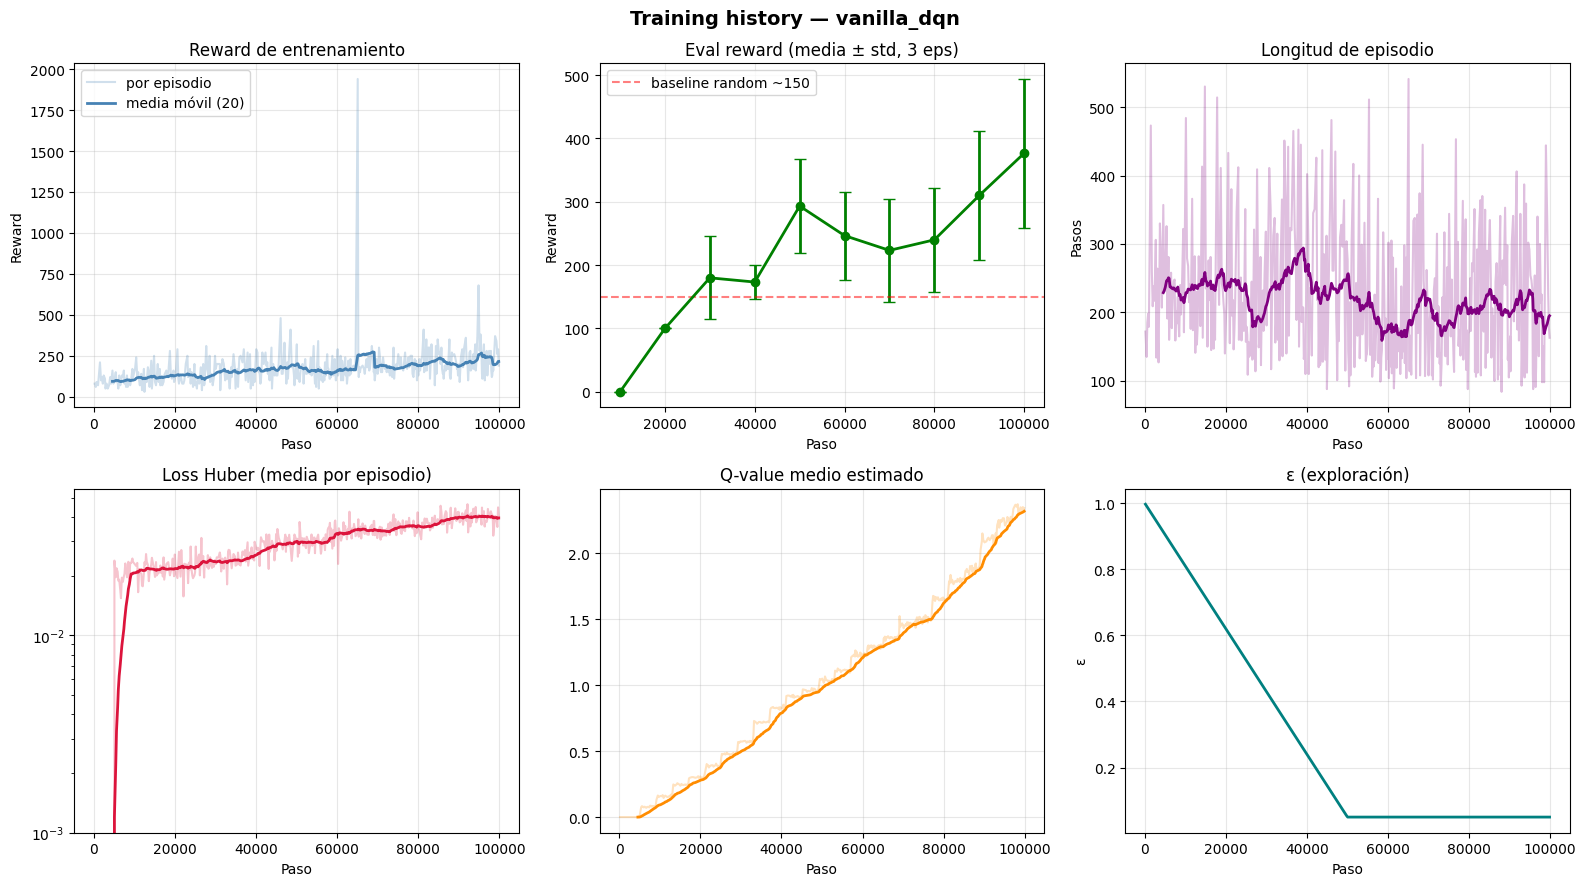

In [23]:
def plot_training_history(history, label="vanilla_dqn", window=20):
    ep_steps   = np.array(history["episode_end_steps"])
    ep_rewards = np.array(history["episode_rewards"])
    ep_lengths = np.array(history["episode_lengths"])
    ep_losses  = np.array(history["episode_losses"])
    ep_qmean   = np.array(history["episode_q_means"])
    ep_eps     = np.array(history["episode_epsilons"])
    eval_x     = np.array(history["eval_steps"])
    eval_mean  = np.array(history["eval_mean_rewards"])
    eval_std   = np.array(history["eval_std_rewards"])

    def smooth(x, w):
        if len(x) < w:
            return x, np.arange(len(x))
        return np.convolve(x, np.ones(w)/w, mode="valid"), np.arange(w-1, len(x))

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Training history — {label}", fontsize=14, fontweight="bold")

    # Reward entrenamiento
    ax = axes[0, 0]
    ax.plot(ep_steps, ep_rewards, alpha=0.25, color="steelblue", label="por episodio")
    s, idx = smooth(ep_rewards, window)
    ax.plot(ep_steps[idx], s, color="steelblue", lw=2, label=f"media móvil ({window})")
    ax.set_title("Reward de entrenamiento")
    ax.set_xlabel("Paso")
    ax.set_ylabel("Reward")
    ax.legend(); ax.grid(alpha=0.3)

    # Reward evaluación
    ax = axes[0, 1]
    ax.errorbar(eval_x, eval_mean, yerr=eval_std, marker="o",
                color="green", capsize=4, lw=2)
    ax.axhline(150, color="red", ls="--", alpha=0.5, label="baseline random ~150")
    ax.set_title("Eval reward (media ± std, 3 eps)")
    ax.set_xlabel("Paso"); ax.set_ylabel("Reward")
    ax.legend(); ax.grid(alpha=0.3)

    # Longitud del episodio
    ax = axes[0, 2]
    ax.plot(ep_steps, ep_lengths, alpha=0.25, color="purple")
    s, idx = smooth(ep_lengths, window)
    ax.plot(ep_steps[idx], s, color="purple", lw=2)
    ax.set_title("Longitud de episodio")
    ax.set_xlabel("Paso"); ax.set_ylabel("Pasos")
    ax.grid(alpha=0.3)

    # Loss
    ax = axes[1, 0]
    ax.plot(ep_steps, ep_losses, alpha=0.25, color="crimson")
    s, idx = smooth(ep_losses, window)
    ax.plot(ep_steps[idx], s, color="crimson", lw=2)
    ax.set_title("Loss Huber (media por episodio)")
    ax.set_xlabel("Paso"); ax.set_yscale("log")
    ax.grid(alpha=0.3)

    # Q-mean
    ax = axes[1, 1]
    ax.plot(ep_steps, ep_qmean, alpha=0.25, color="darkorange")
    s, idx = smooth(ep_qmean, window)
    ax.plot(ep_steps[idx], s, color="darkorange", lw=2)
    ax.set_title("Q-value medio estimado")
    ax.set_xlabel("Paso"); ax.grid(alpha=0.3)

    # Epsilon
    ax = axes[1, 2]
    ax.plot(ep_steps, ep_eps, color="teal", lw=2)
    ax.set_title("ε (exploración)")
    ax.set_xlabel("Paso"); ax.set_ylabel("ε")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{label}_training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_training_history(history_vanilla, label="vanilla_dqn", window=20)

# Agente Alien

✓ GIF guardado: vanilla_play.gif  (1051 frames, 0.3 MB)
  Rewards por episodio: ['210', '230']
  Media: 220.0   Máx: 230


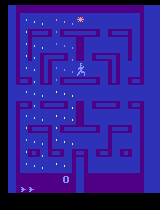

In [49]:
!pip install -q imageio

import imageio.v2 as imageio
from IPython.display import Image, display


def record_agent(agent, n_episodes: int = 2, seed_base: int = 2000,
                filename: str = "agent_play.gif", max_frames: int = 2000):
    """Graba al agente jugando en modo greedy y guarda un GIF."""
    env = make_env_eval(seed=seed_base, render_mode="rgb_array")
    frames = []
    ep_rewards = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed_base + ep)
        ep_r, done = 0.0, False
        while not done:
            frame = env.render()
            if frame is not None:
                frames.append(frame)
            action = agent.select_action(np.array(obs), step=0, eval_mode=True)
            obs, r, term, trunc, _ = env.step(action)
            ep_r += r
            done = term or trunc
            if len(frames) >= max_frames:
                break
        ep_rewards.append(ep_r)
        if len(frames) >= max_frames:
            break

    env.close()

    # 15 fps ≈ velocidad real del juego (Atari 60 fps / frame_skip 4)
    imageio.mimsave(filename, frames, fps=15, loop=0)
    size_mb = __import__("os").path.getsize(filename) / 1024**2

    print(f"✓ GIF guardado: {filename}  ({len(frames)} frames, {size_mb:.1f} MB)")
    print(f"  Rewards por episodio: {[f'{r:.0f}' for r in ep_rewards]}")
    print(f"  Media: {np.mean(ep_rewards):.1f}   Máx: {max(ep_rewards):.0f}")
    return filename


gif = record_agent(agent_vanilla, n_episodes=2, filename="vanilla_play.gif")
display(Image(gif))

### Probando otras arquitecturas

In [25]:
# Config común — igual a vanilla para comparación limpia
BASE_KW = dict(
    n_actions=18, learning_rate=1e-4, batch_size=32, gamma=0.99, grad_clip=10.0,
    buffer_capacity=50_000, min_buffer_size=5_000, target_update_freq=1_000,
    eps_start=1.0, eps_end=0.05, eps_decay_steps=50_000, reward_clip=1.0,
    train_every=4,
)

cfg_double         = DQNConfig(**BASE_KW, double_dqn=True,  label="double_dqn")
cfg_dueling        = DQNConfig(**BASE_KW, double_dqn=False, label="dueling_dqn")
cfg_double_dueling = DQNConfig(**BASE_KW, double_dqn=True,  label="double_dueling_dqn")

for c in (cfg_double, cfg_dueling, cfg_double_dueling):
    print(f"{c.label:22s}  double={c.double_dqn}")

double_dqn              double=True
dueling_dqn             double=False
double_dueling_dqn      double=True


In [26]:
## Double DQN

In [30]:
TOTAL_STEPS = 100_000                                                                                                               
                                                                                                                                    
agent_double = DQNAgent(network_cls=VanillaDQN, config=cfg_double, device=DEVICE)                                                   
history_double = train(                                                                                                             
    agent=agent_double,                                                                                                             
    config=cfg_double,
    total_steps=TOTAL_STEPS,
    eval_every=10_000,
    n_eval_episodes=3,
    seed=1,
)

torch.save(agent_double.q_net.state_dict(), "double_dqn_weights.pt")
with open("double_dqn_run.pkl", "wb") as f:
    pickle.dump(history_double, f)

Training double_dqn:   0%|          | 0/100000 [00:00<?, ?it/s]

[step  10,000]  eval reward =   100.0 ± 0.0
[step  20,000]  eval reward =   200.0 ± 71.2
[step  30,000]  eval reward =   263.3 ± 20.5
[step  40,000]  eval reward =   503.3 ± 360.6
[step  50,000]  eval reward =   296.7 ± 9.4
[step  60,000]  eval reward =   293.3 ± 75.9
[step  70,000]  eval reward =   386.7 ± 62.4
[step  80,000]  eval reward =   226.7 ± 33.0
[step  90,000]  eval reward =   286.7 ± 65.5
[step 100,000]  eval reward =   246.7 ± 20.5


### Dueling DQN

In [31]:
agent_dueling = DQNAgent(network_cls=DuelingDQN, config=cfg_dueling, device=DEVICE)
history_dueling = train(
    agent=agent_dueling,
    config=cfg_dueling,
    total_steps=TOTAL_STEPS,
    eval_every=10_000,
    n_eval_episodes=3,
    seed=2,
)

torch.save(agent_dueling.q_net.state_dict(), "dueling_dqn_weights.pt")
with open("dueling_dqn_run.pkl", "wb") as f:
    pickle.dump(history_dueling, f)

Training dueling_dqn:   0%|          | 0/100000 [00:00<?, ?it/s]

[step  10,000]  eval reward =     0.0 ± 0.0
[step  20,000]  eval reward =    36.7 ± 4.7
[step  30,000]  eval reward =    83.3 ± 18.9
[step  40,000]  eval reward =   220.0 ± 43.2
[step  50,000]  eval reward =   313.3 ± 96.7
[step  60,000]  eval reward =   293.3 ± 34.0
[step  70,000]  eval reward =   270.0 ± 49.7
[step  80,000]  eval reward =   423.3 ± 102.1
[step  90,000]  eval reward =   393.3 ± 55.6
[step 100,000]  eval reward =   496.7 ± 59.1


### Double + Dueling

In [32]:
agent_dd = DQNAgent(network_cls=DuelingDQN, config=cfg_double_dueling, device=DEVICE)
history_dd = train(
    agent=agent_dd,
    config=cfg_double_dueling,
    total_steps=TOTAL_STEPS,
    eval_every=10_000,
    n_eval_episodes=3,
    seed=3,
)

torch.save(agent_dd.q_net.state_dict(), "double_dueling_dqn_weights.pt")
with open("double_dueling_dqn_run.pkl", "wb") as f:
    pickle.dump(history_dd, f)

Training double_dueling_dqn:   0%|          | 0/100000 [00:00<?, ?it/s]

[step  10,000]  eval reward =     0.0 ± 0.0
[step  20,000]  eval reward =   176.7 ± 51.9
[step  30,000]  eval reward =   326.7 ± 40.3
[step  40,000]  eval reward =   253.3 ± 28.7
[step  50,000]  eval reward =   213.3 ± 61.3
[step  60,000]  eval reward =   356.7 ± 66.5
[step  70,000]  eval reward =   386.7 ± 23.6
[step  80,000]  eval reward =   720.0 ± 397.3
[step  90,000]  eval reward =   496.7 ± 117.3
[step 100,000]  eval reward =   610.0 ± 89.8


### Verificando resultados

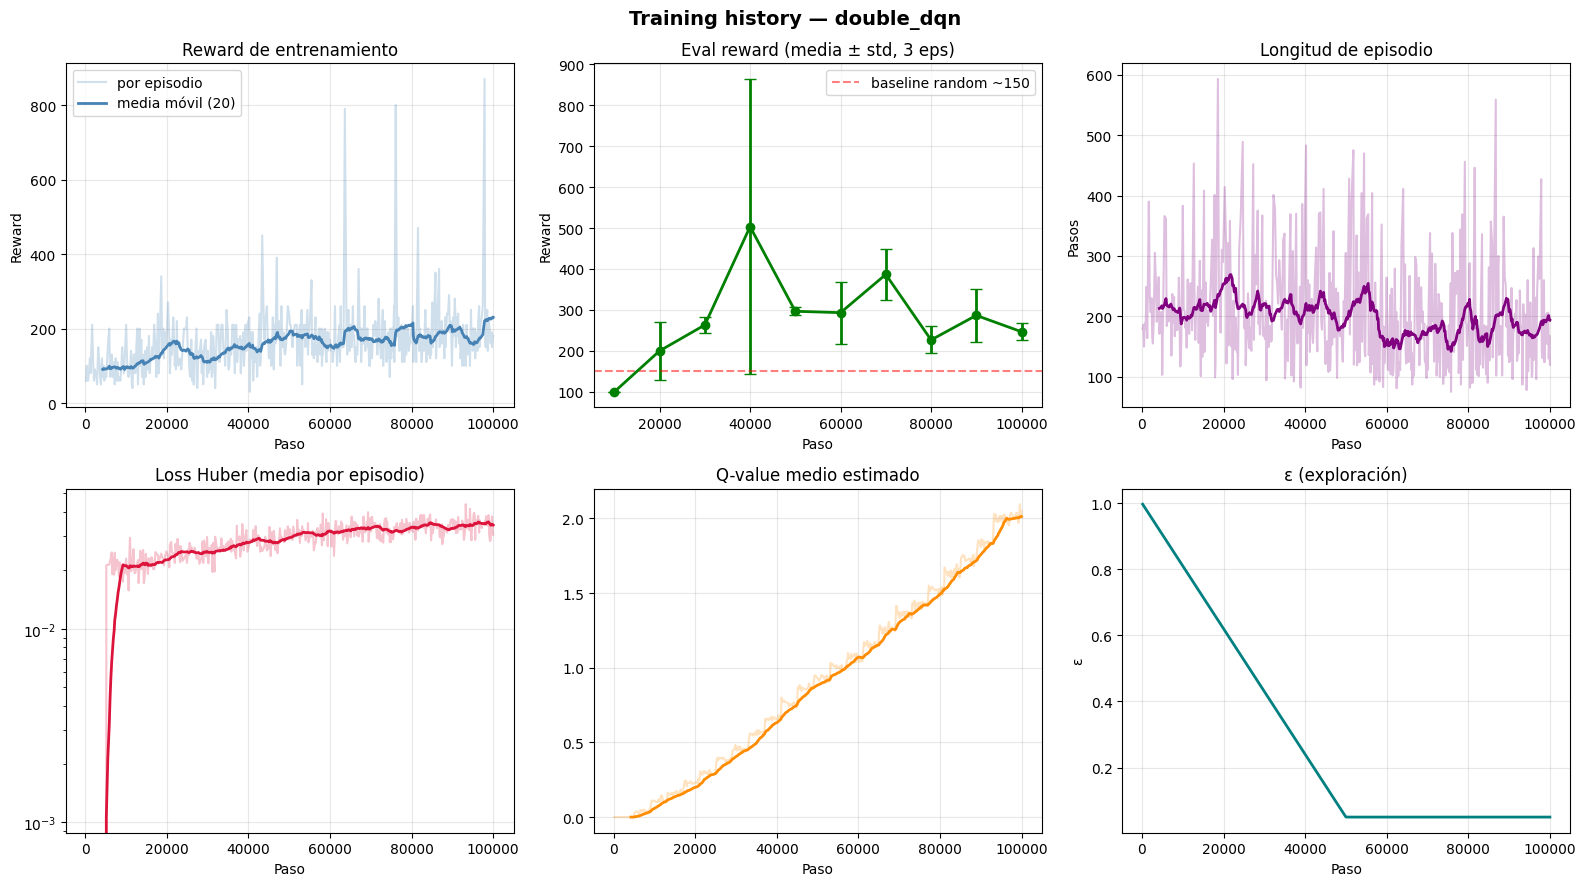

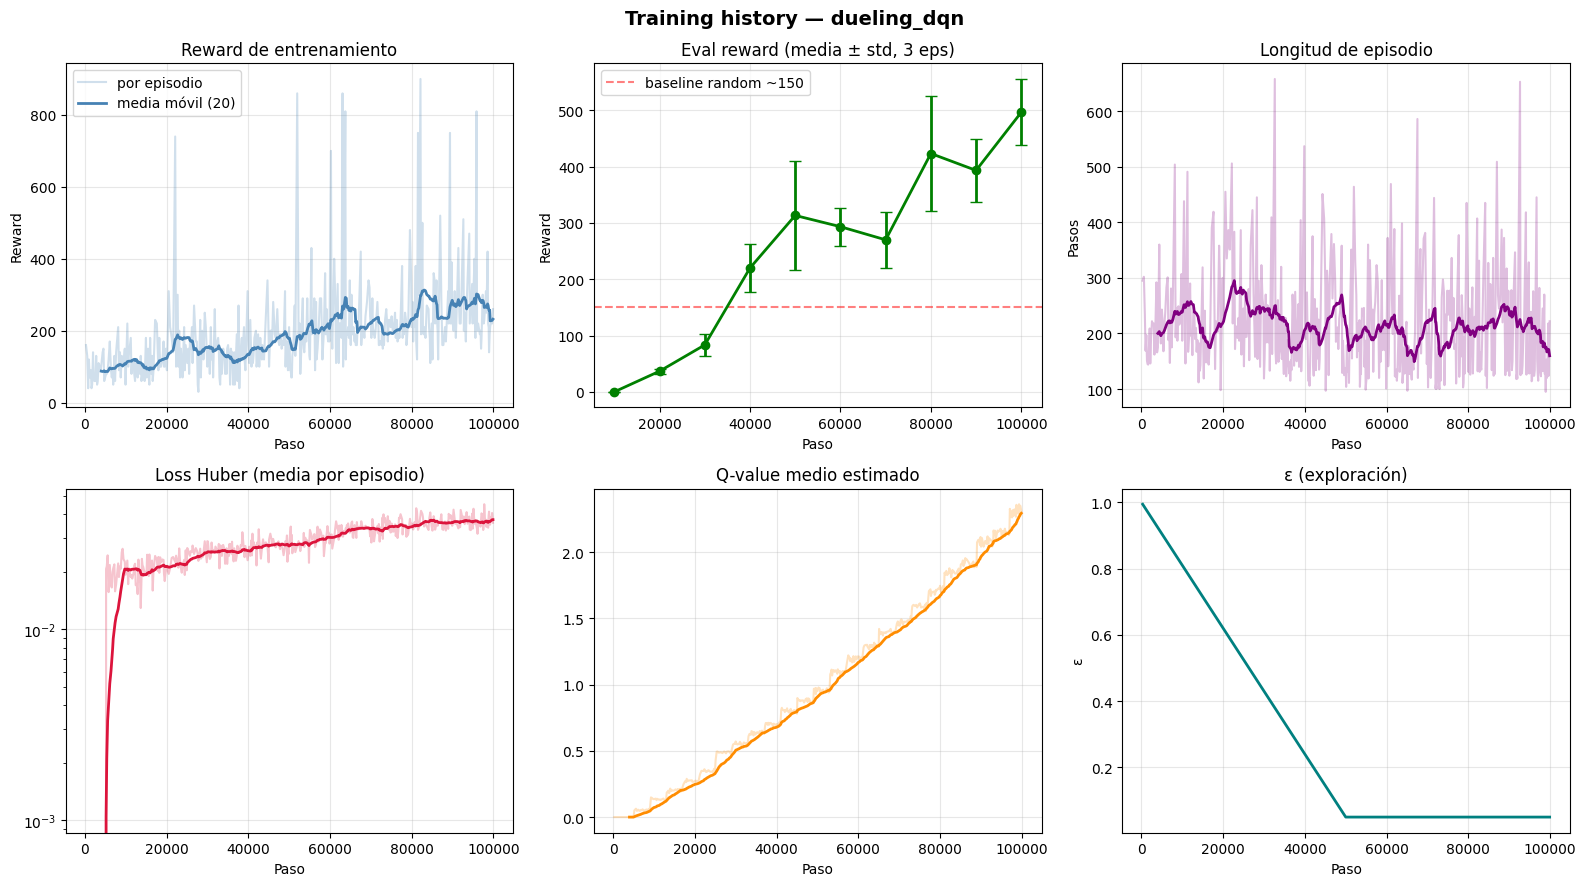

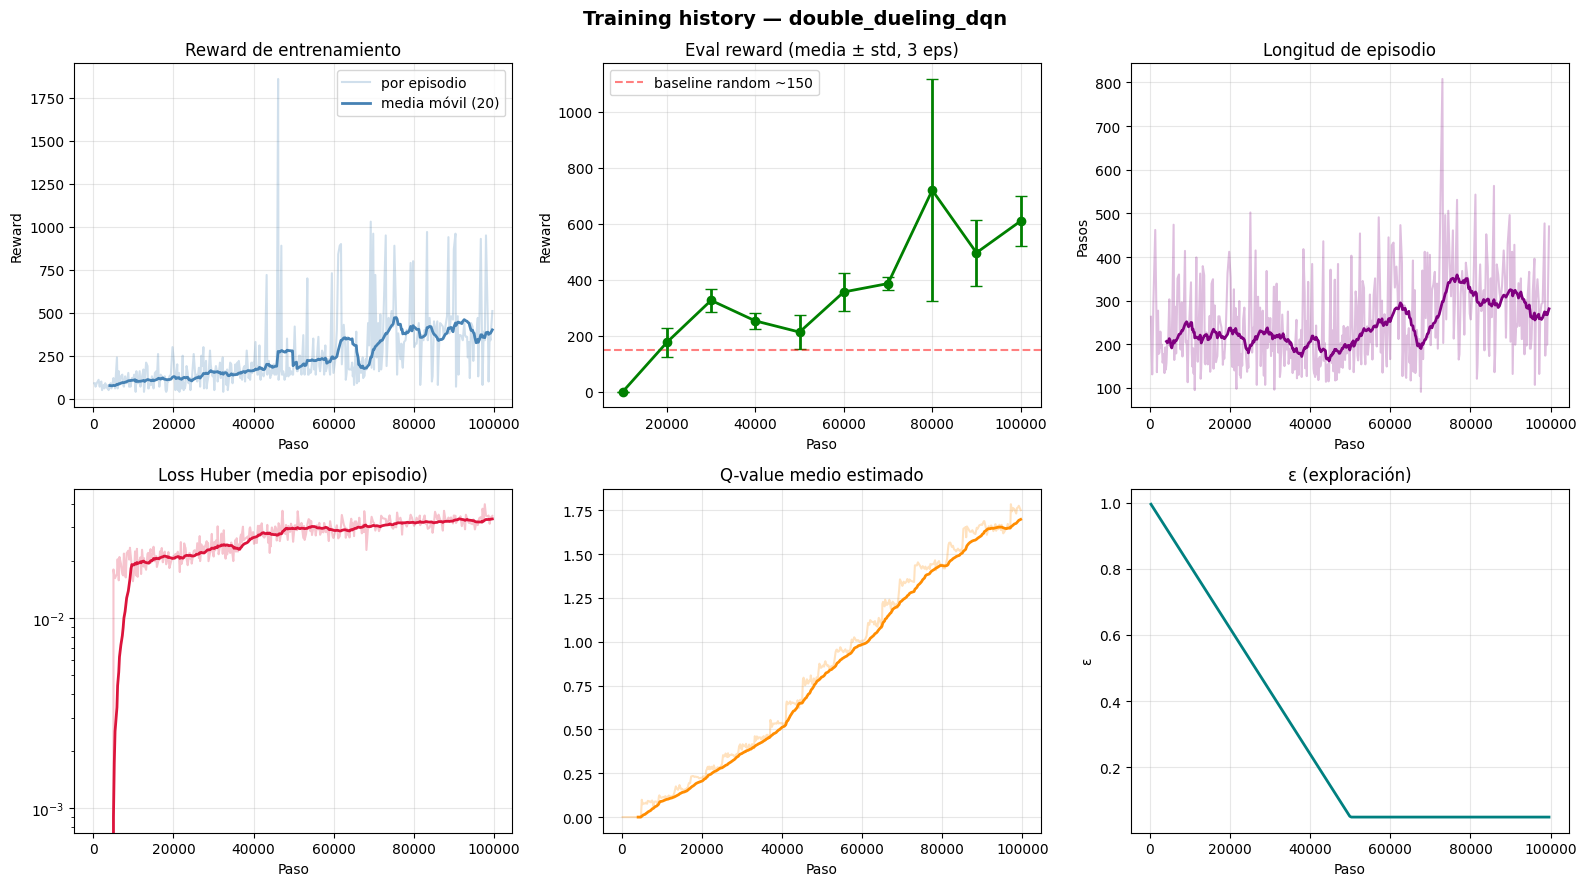

In [33]:
plot_training_history(history_double,  label="double_dqn",         window=20)
plot_training_history(history_dueling, label="dueling_dqn",        window=20)
plot_training_history(history_dd,      label="double_dueling_dqn", window=20)

### Comparando resultados

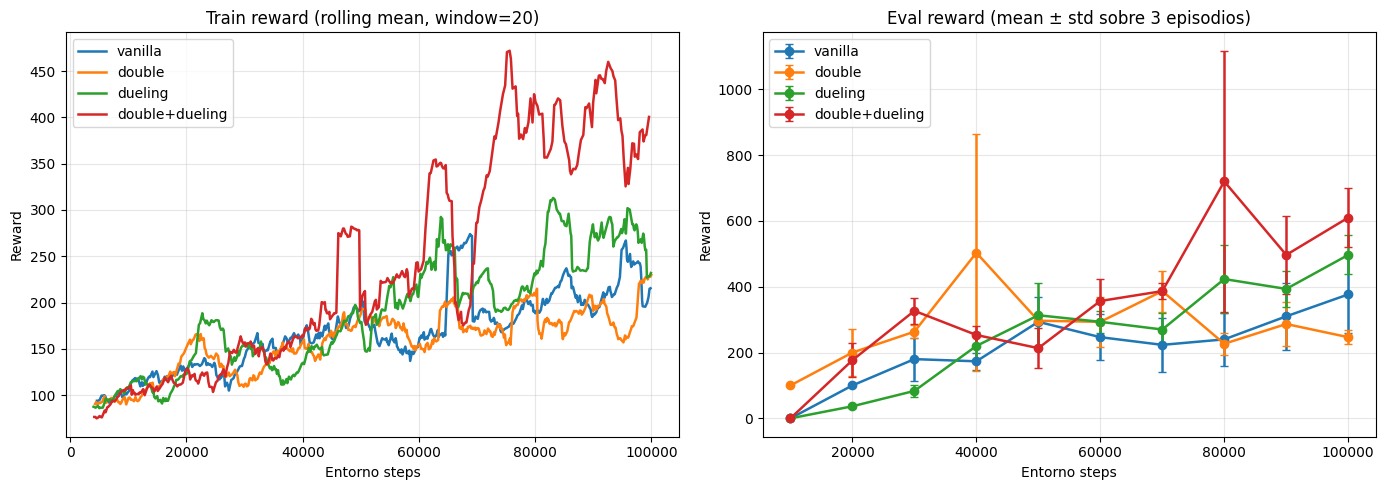

In [34]:
def compare_histories(histories, window=20):
    """
    histories: dict {label: history_dict}
    Grafica eval_reward y rolling train_reward de todos en los mismos ejes.
    """
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel 1: train reward (rolling mean) ──
    for label, h in histories.items():
        ep_r = np.array(h["episode_rewards"])
        if len(ep_r) >= window:
            rolling = np.convolve(ep_r, np.ones(window)/window, mode="valid")
            x = h["episode_end_steps"][window-1:]
            axs[0].plot(x, rolling, label=label, linewidth=1.8)
    axs[0].set_title(f"Train reward (rolling mean, window={window})")
    axs[0].set_xlabel("Entorno steps"); axs[0].set_ylabel("Reward")
    axs[0].legend(); axs[0].grid(alpha=0.3)

    # ── Panel 2: eval reward con error bars ──
    for label, h in histories.items():
        axs[1].errorbar(h["eval_steps"], h["eval_mean_rewards"],
                        yerr=h["eval_std_rewards"], marker="o", capsize=3,
                        label=label, linewidth=1.8)
    axs[1].set_title("Eval reward (mean ± std sobre 3 episodios)")
    axs[1].set_xlabel("Entorno steps"); axs[1].set_ylabel("Reward")
    axs[1].legend(); axs[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

all_histories = {
    "vanilla":         history_vanilla,
    "double":          history_double,
    "dueling":         history_dueling,
    "double+dueling":  history_dd,
}
compare_histories(all_histories, window=20)

### Resumen de resultados

In [35]:
import pandas as pd

rows = []
for label, h in all_histories.items():
    final_eval = h["eval_mean_rewards"][-1]
    best_eval  = max(h["eval_mean_rewards"])
    best_step  = h["eval_steps"][int(np.argmax(h["eval_mean_rewards"]))]
    last20     = np.mean(h["episode_rewards"][-20:])
    rows.append({
        "variante": label,
        "eval final":   f"{final_eval:.1f}",
        "eval mejor":   f"{best_eval:.1f}",
        "step mejor":   f"{best_step:,}",
        "train últ.20": f"{last20:.1f}",
        "episodios":    len(h["episode_rewards"]),
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

      variante eval final eval mejor step mejor train últ.20  episodios
       vanilla      376.7      376.7    100,000        215.5        464
        double      246.7      503.3     40,000        230.0        509
       dueling      496.7      496.7    100,000        232.0        471
double+dueling      610.0      720.0     80,000        400.5        418


In [51]:
record_agent(agent_vanilla, filename="vanilla_play.gif",        n_episodes=2)
record_agent(agent_double,  filename="double_play.gif",         n_episodes=2)
record_agent(agent_dueling, filename="dueling_play.gif",        n_episodes=2)
record_agent(agent_dd,      filename="double_dueling_play.gif", n_episodes=2)

import base64
from pathlib import Path
from IPython.display import HTML, display

gif_files = [
    ("Vanilla DQN",        "vanilla_play.gif",         history_vanilla),
    ("Double DQN",         "double_play.gif",          history_double),
    ("Dueling DQN",        "dueling_play.gif",         history_dueling),
    ("Double + Dueling",   "double_dueling_play.gif",  history_dd),
]


✓ GIF guardado: vanilla_play.gif  (1051 frames, 0.3 MB)
  Rewards por episodio: ['210', '230']
  Media: 220.0   Máx: 230
✓ GIF guardado: double_play.gif  (1758 frames, 0.5 MB)
  Rewards por episodio: ['1030', '4000']
  Media: 2515.0   Máx: 4000
✓ GIF guardado: dueling_play.gif  (1010 frames, 0.3 MB)
  Rewards por episodio: ['500', '360']
  Media: 430.0   Máx: 500
✓ GIF guardado: double_dueling_play.gif  (1615 frames, 0.5 MB)
  Rewards por episodio: ['1050', '630']
  Media: 840.0   Máx: 1050



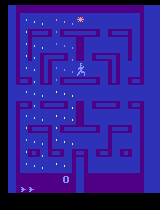
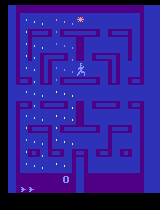
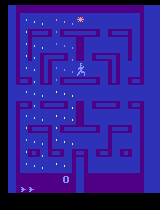
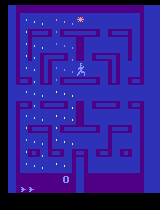

In [52]:
html_parts = ['<div style="display:flex;flex-direction:column;gap:18px;align-items:center;">']
def _embed_gif(path):
    data = Path(path).read_bytes()
    b64 = base64.b64encode(data).decode("ascii")
    return f'<img src="data:image/gif;base64,{b64}" style="max-width:360px;display:block;margin:0 auto;border:2px solid#333;border-radius:8px;">'

html_parts.clear()

for title, path, hist in gif_files:
    if not Path(path).exists():
        html_parts.append(
            f'<div style="text-align:center;color:#c0392b;"><b>{title}</b><br>'
            f'(falta {path} — ejecuta record_agent antes)</div>'
        )
        continue

    best  = max(hist["eval_mean_rewards"])
    final = hist["eval_mean_rewards"][-1]
    html_parts.append(
        f'<div style="text-align:center;">'
        f'<div style="font-weight:bold;font-size:14px;margin-bottom:4px;">{title}</div>'
        f'<div style="font-size:12px;color:#555;margin-bottom:6px;">'
        f'eval final: {final:.1f} &nbsp;|&nbsp; mejor eval: {best:.1f}</div>'
        f'{_embed_gif(path)}'
        f'</div>'
    )


html_parts.append("</div>")
display(HTML("".join(html_parts)))